<a href="https://colab.research.google.com/github/Abishekabi19/ML-and-DL-Project/blob/main/Campus_Placement/Campus_placement_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statement
100,000 synthetic student profiles for predicting campus placement outcomes. Features 26 columns covering academics (SSC/HSC/Degree scores), skills (technical, soft, aptitude), experience (internships, projects, certifications), and extras (leadership, extracurriculars, backlogs). Includes dual targets: binary placement status and salary in LPA. Realistic correlations mirror actual campus recruitment patterns.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/campus_placement_data.csv')
df

,student_id,gender,age,city_tier,ssc_percentage,ssc_board,hsc_percentage,hsc_board,hsc_stream,degree_percentage,...,technical_skills_score,soft_skills_score,aptitude_score,communication_score,work_experience_months,leadership_roles,extracurricular_activities,backlogs,placed,salary_lpa
0,STU000001,Male,22,Tier 1,71.01,State,76.76,CBSE,Commerce,64.44,...,6.8,7.8,62.1,6.2,14,1,10,0,1,12.24
1,STU000002,Female,22,Tier 2,58.46,CBSE,57.62,State,Science,68.24,...,4.6,4.8,58.7,7.2,5,1,4,0,1,10.09
2,STU000003,Female,21,Tier 1,67.83,CBSE,65.67,State,Commerce,52.33,...,4.7,5.0,58.9,5.0,30,2,1,0,1,14.94
3,STU000004,Female,21,Tier 2,80.40,CBSE,77.15,State,Science,56.55,...,6.8,7.6,35.0,8.3,31,0,5,0,1,15.49
4,STU000005,Male,21,Tier 1,66.10,State,62.81,ICSE,Science,78.93,...,7.0,5.7,54.0,5.4,24,0,2,0,1,15.13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,STU099996,Female,22,Tier 1,70.03,CBSE,58.73,State,Arts,48.01,...,10.0,10.0,57.4,10.0,10,1,0,5,1,12.36
99996,STU099997,Female,22,Tier 2,81.48,CBSE,65.48,State,Commerce,45.00,...,6.0,8.4,56.5,9.2,7,2,4,0,1,10.64
99997,STU099998,Female,20,Tier 2,79.29,State,70.13,State,Commerce,75.24,...,6.6,7.0,38.0,7.1,10,1,4,1,1,13.05
99998,STU099999,Male,22,Tier 1,74.81,CBSE,74.79,CBSE,Commerce,92.22,...,4.9,8.2,81.3,8.3,0,1,4,0,1,12.52


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   student_id                  100000 non-null  object 
 1   gender                      100000 non-null  object 
 2   age                         100000 non-null  int64  
 3   city_tier                   100000 non-null  object 
 4   ssc_percentage              100000 non-null  float64
 5   ssc_board                   100000 non-null  object 
 6   hsc_percentage              100000 non-null  float64
 7   hsc_board                   100000 non-null  object 
 8   hsc_stream                  100000 non-null  object 
 9   degree_percentage           100000 non-null  float64
 10  degree_field                100000 non-null  object 
 11  mba_percentage              100000 non-null  float64
 12  specialization              35035 non-null   object 
 13  internships_cou

In [ ]:
df.isnull().sum()

,0
student_id,0
gender,0
age,0
city_tier,0
ssc_percentage,0
ssc_board,0
hsc_percentage,0
hsc_board,0
hsc_stream,0
degree_percentage,0


In [ ]:
df.drop('specialization',axis=1,inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
dumies=pd.get_dummies(df['gender']).astype(int)
dumies

,Female,Male,Other
0,0,1,0
1,1,0,0
2,1,0,0
3,1,0,0
4,0,1,0
...,...,...,...
99995,1,0,0
99996,1,0,0
99997,1,0,0
99998,0,1,0


In [ ]:
df=pd.concat([df,dumies],axis='columns')
df

,student_id,gender,age,city_tier,ssc_percentage,ssc_board,hsc_percentage,hsc_board,hsc_stream,degree_percentage,...,communication_score,work_experience_months,leadership_roles,extracurricular_activities,backlogs,placed,salary_lpa,Female,Male,Other
0,STU000001,Male,22,Tier 1,71.01,State,76.76,CBSE,Commerce,64.44,...,6.2,14,1,10,0,1,12.24,0,1,0
1,STU000002,Female,22,Tier 2,58.46,CBSE,57.62,State,Science,68.24,...,7.2,5,1,4,0,1,10.09,1,0,0
2,STU000003,Female,21,Tier 1,67.83,CBSE,65.67,State,Commerce,52.33,...,5.0,30,2,1,0,1,14.94,1,0,0
3,STU000004,Female,21,Tier 2,80.40,CBSE,77.15,State,Science,56.55,...,8.3,31,0,5,0,1,15.49,1,0,0
4,STU000005,Male,21,Tier 1,66.10,State,62.81,ICSE,Science,78.93,...,5.4,24,0,2,0,1,15.13,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,STU099996,Female,22,Tier 1,70.03,CBSE,58.73,State,Arts,48.01,...,10.0,10,1,0,5,1,12.36,1,0,0
99996,STU099997,Female,22,Tier 2,81.48,CBSE,65.48,State,Commerce,45.00,...,9.2,7,2,4,0,1,10.64,1,0,0
99997,STU099998,Female,20,Tier 2,79.29,State,70.13,State,Commerce,75.24,...,7.1,10,1,4,1,1,13.05,1,0,0
99998,STU099999,Male,22,Tier 1,74.81,CBSE,74.79,CBSE,Commerce,92.22,...,8.3,0,1,4,0,1,12.52,0,1,0


In [ ]:
df.drop('gender',axis=1,inplace=True)

In [ ]:
df

,student_id,age,city_tier,ssc_percentage,ssc_board,hsc_percentage,hsc_board,hsc_stream,degree_percentage,degree_field,...,communication_score,work_experience_months,leadership_roles,extracurricular_activities,backlogs,placed,salary_lpa,Female,Male,Other
0,STU000001,22,Tier 1,71.01,State,76.76,CBSE,Commerce,64.44,Engineering,...,6.2,14,1,10,0,1,12.24,0,1,0
1,STU000002,22,Tier 2,58.46,CBSE,57.62,State,Science,68.24,Business,...,7.2,5,1,4,0,1,10.09,1,0,0
2,STU000003,21,Tier 1,67.83,CBSE,65.67,State,Commerce,52.33,Engineering,...,5.0,30,2,1,0,1,14.94,1,0,0
3,STU000004,21,Tier 2,80.40,CBSE,77.15,State,Science,56.55,Engineering,...,8.3,31,0,5,0,1,15.49,1,0,0
4,STU000005,21,Tier 1,66.10,State,62.81,ICSE,Science,78.93,Engineering,...,5.4,24,0,2,0,1,15.13,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,STU099996,22,Tier 1,70.03,CBSE,58.73,State,Arts,48.01,Business,...,10.0,10,1,0,5,1,12.36,1,0,0
99996,STU099997,22,Tier 2,81.48,CBSE,65.48,State,Commerce,45.00,Engineering,...,9.2,7,2,4,0,1,10.64,1,0,0
99997,STU099998,20,Tier 2,79.29,State,70.13,State,Commerce,75.24,Engineering,...,7.1,10,1,4,1,1,13.05,1,0,0
99998,STU099999,22,Tier 1,74.81,CBSE,74.79,CBSE,Commerce,92.22,Arts,...,8.3,0,1,4,0,1,12.52,0,1,0


In [ ]:
df['city_tier'].unique()

array(['Tier 1', 'Tier 2', 'Tier 3'], dtype=object)

In [ ]:
df['city_tier'].replace(['Tier 1', 'Tier 2', 'Tier 3'],[1,2,3],inplace=True)

/tmp/ipython-input-2450169323.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['city_tier'].replace(['Tier 1', 'Tier 2', 'Tier 3'],[1,2,3],inplace=True)
/tmp/ipython-input-2450169323.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['city_tier'].replace(['Tier 1', 'Tier 2', 'Tier 3'],[1,2

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   student_id                  100000 non-null  object 
 1   age                         100000 non-null  int64  
 2   city_tier                   100000 non-null  int64  
 3   ssc_percentage              100000 non-null  float64
 4   ssc_board                   100000 non-null  object 
 5   hsc_percentage              100000 non-null  float64
 6   hsc_board                   100000 non-null  object 
 7   hsc_stream                  100000 non-null  object 
 8   degree_percentage           100000 non-null  float64
 9   degree_field                100000 non-null  object 
 10  mba_percentage              100000 non-null  float64
 11  internships_count           100000 non-null  int64  
 12  projects_count              100000 non-null  int64  
 13  certifications_

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['student_id']=le.fit_transform(df['student_id'])
df['ssc_board']=le.fit_transform(df['ssc_board'])
df['hsc_board']=le.fit_transform(df['hsc_board'])
df['hsc_stream']=le.fit_transform(df['hsc_stream'])
df['degree_field']=le.fit_transform(df['degree_field'])


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   student_id                  100000 non-null  int64  
 1   age                         100000 non-null  int64  
 2   city_tier                   100000 non-null  int64  
 3   ssc_percentage              100000 non-null  float64
 4   ssc_board                   100000 non-null  int64  
 5   hsc_percentage              100000 non-null  float64
 6   hsc_board                   100000 non-null  int64  
 7   hsc_stream                  100000 non-null  int64  
 8   degree_percentage           100000 non-null  float64
 9   degree_field                100000 non-null  int64  
 10  mba_percentage              100000 non-null  float64
 11  internships_count           100000 non-null  int64  
 12  projects_count              100000 non-null  int64  
 13  certifications_

<Axes: >

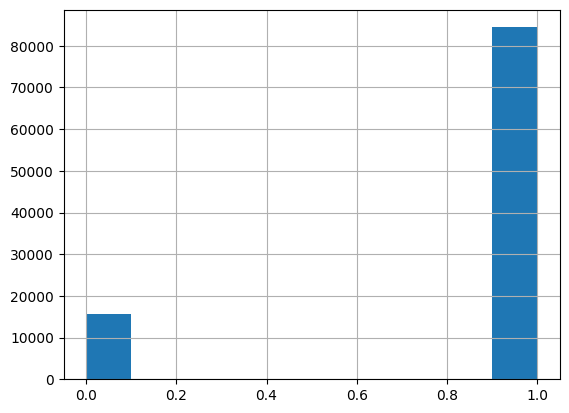

In [ ]:
df['placed'].hist()

In [ ]:
X=df.drop(columns=['placed'])
y=df['placed']

In [ ]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_smote,y_smote=smote.fit_resample(X,y)

df=pd.concat([pd.DataFrame(X_smote,columns=X.columns),
              pd.Series(y_smote,name=y.name)],axis=1)

<Axes: >

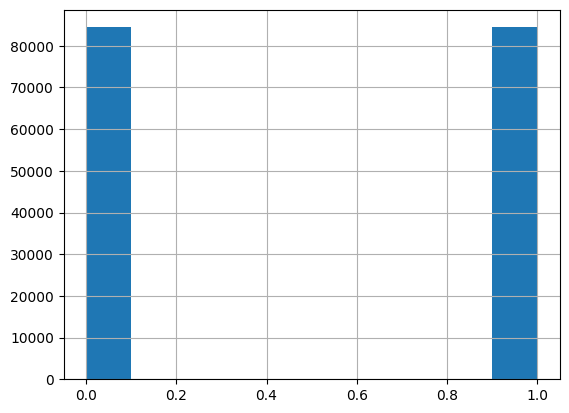

In [ ]:
df['placed'].hist()

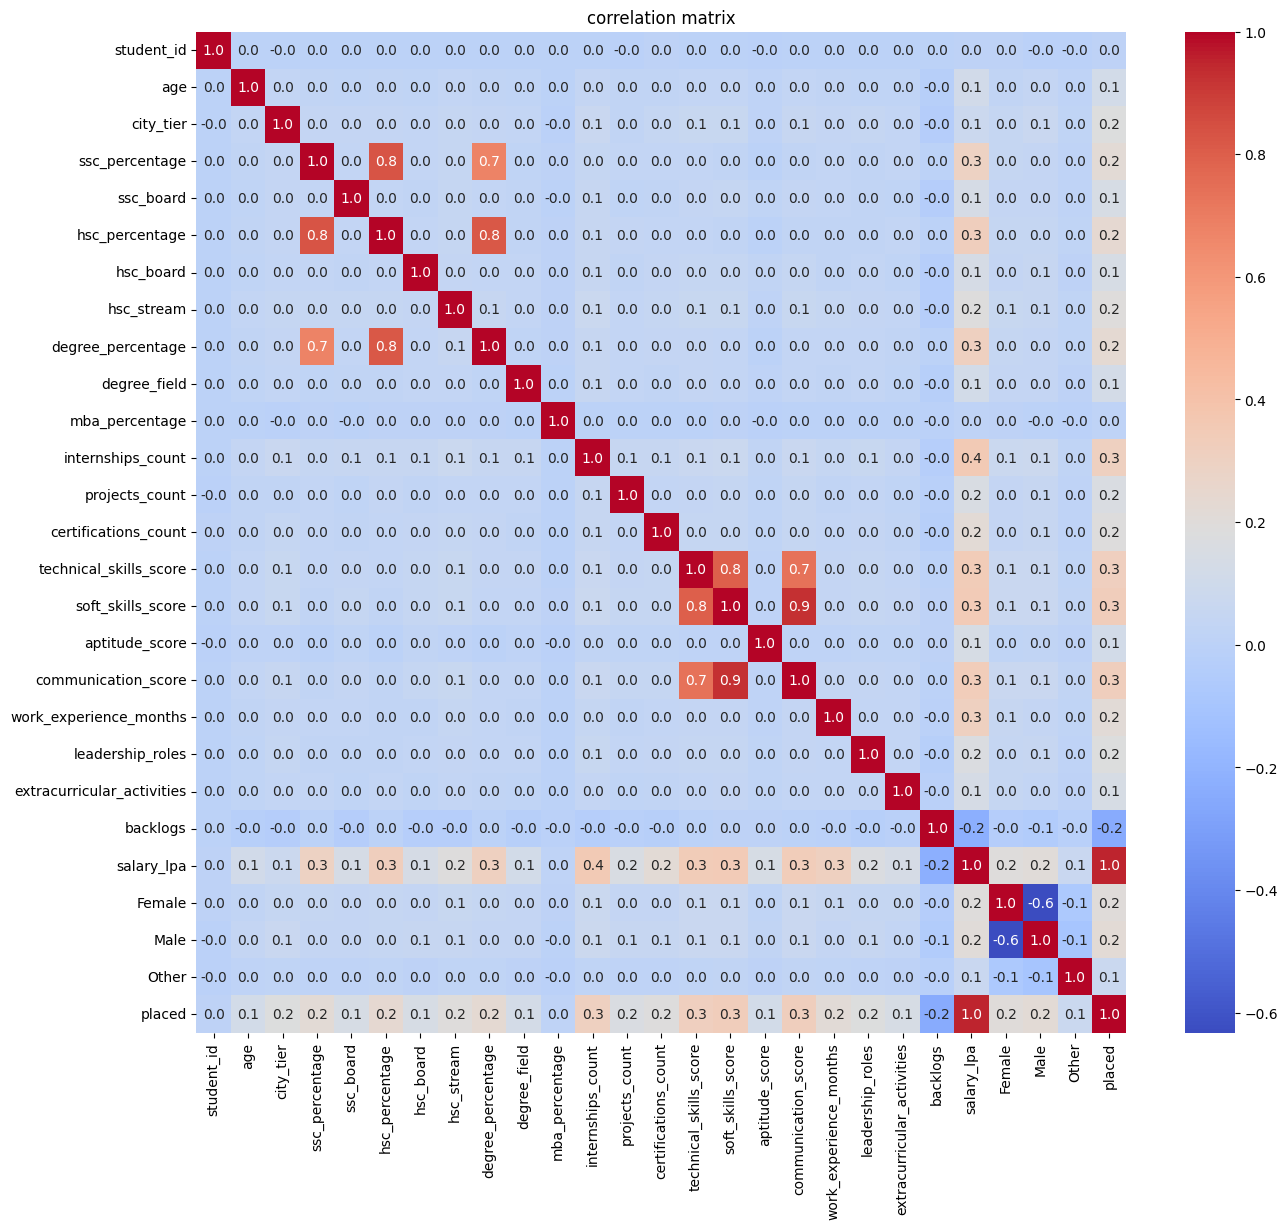

In [ ]:
plt.figure(figsize=(15,13))
corr_matrix=df.corr()
sns.heatmap(corr_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title('correlation matrix')
plt.show()

In [ ]:
df.drop(['ssc_percentage','hsc_percentage','technical_skills_score','soft_skills_score'],axis=1,inplace=True)

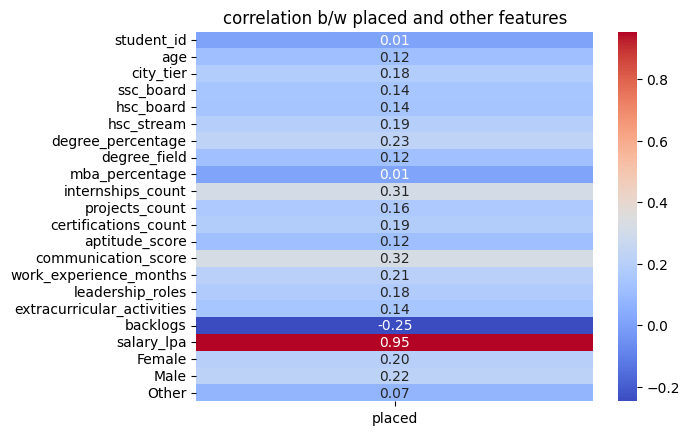

In [ ]:
placed_corr=df.corr()['placed']
placed_corr=placed_corr.drop('placed')
sns.heatmap(placed_corr.to_frame(),annot=True,fmt='0.2f',cmap='coolwarm',annot_kws={'size':10})
plt.title('correlation b/w placed and other features')
plt.show()

In [ ]:
df.drop(['student_id','mba_percentage','Other'],axis=1,inplace=True)

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20]),
 [Text(1, 0, 'age'),
  Text(2, 0, 'city_tier'),
  Text(3, 0, 'ssc_board'),
  Text(4, 0, 'hsc_board'),
  Text(5, 0, 'hsc_stream'),
  Text(6, 0, 'degree_percentage'),
  Text(7, 0, 'degree_field'),
  Text(8, 0, 'internships_count'),
  Text(9, 0, 'projects_count'),
  Text(10, 0, 'certifications_count'),
  Text(11, 0, 'aptitude_score'),
  Text(12, 0, 'communication_score'),
  Text(13, 0, 'work_experience_months'),
  Text(14, 0, 'leadership_roles'),
  Text(15, 0, 'extracurricular_activities'),
  Text(16, 0, 'backlogs'),
  Text(17, 0, 'salary_lpa'),
  Text(18, 0, 'Female'),
  Text(19, 0, 'Male'),
  Text(20, 0, 'placed')])

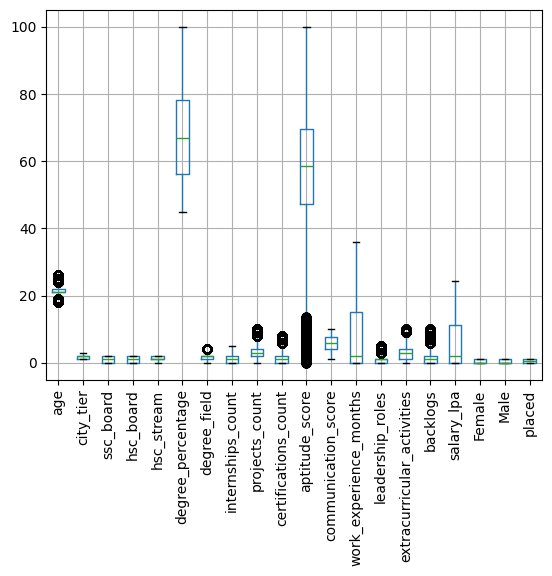

In [ ]:
df.boxplot()
plt.xticks(rotation=90)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scale=MinMaxScaler()

features=['age','city_tier','ssc_board','hsc_board','hsc_stream','degree_percentage','degree_field','internships_count','projects_count','certifications_count',
          'aptitude_score','communication_score','work_experience_months','leadership_roles','extracurricular_activities','backlogs','salary_lpa','Female','Male']

scaled=scale.fit_transform(df[features])
scaled_df=pd.DataFrame(scaled,columns=features)

In [ ]:
df

,age,city_tier,ssc_board,hsc_board,hsc_stream,degree_percentage,degree_field,internships_count,projects_count,certifications_count,aptitude_score,communication_score,work_experience_months,leadership_roles,extracurricular_activities,backlogs,salary_lpa,Female,Male,placed
0,22,1,2,0,1,64.440000,2,1,2,2,62.100000,6.200000,14,1,10,0,12.24,0,1,1
1,22,2,0,2,2,68.240000,1,1,1,2,58.700000,7.200000,5,1,4,0,10.09,1,0,1
2,21,1,0,2,1,52.330000,2,4,3,2,58.900000,5.000000,30,2,1,0,14.94,1,0,1
3,21,2,0,2,2,56.550000,2,2,3,3,35.000000,8.300000,31,0,5,0,15.49,1,0,1
4,21,1,2,1,2,78.930000,2,1,4,2,54.000000,5.400000,24,0,2,0,15.13,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168859,21,2,0,0,2,64.532483,2,0,2,0,31.938585,6.870153,0,0,5,0,0.00,1,0,0
168860,22,2,1,2,1,51.852977,2,0,7,3,60.289081,4.060432,0,0,0,0,0.00,0,0,0
168861,21,3,2,2,2,61.822704,2,1,5,0,41.699304,4.597746,15,0,3,2,0.00,0,0,0
168862,22,1,0,0,0,61.621191,2,1,2,4,61.284012,2.422895,0,0,3,2,0.00,1,0,0


In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

x=scaled_df
y=df['placed']

kf=KFold(n_splits=6,shuffle=True,random_state=42)

model=LogisticRegression()

best_accuracy=0
best_fold=-1

best_x_train=None
best_y_train=None
best_x_test=None
best_y_test=None
best_y_pred=None

for fold,(train_index,test_index) in enumerate(kf.split(x),1):
  x_train,x_test=x.iloc[train_index],x.iloc[test_index]
  y_train,y_test=y.iloc[train_index],y.iloc[test_index]

  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)
  acc=accuracy_score(y_test,y_pred)
  print(f'Accuracy:{acc}')

  if acc>best_accuracy:
    best_accuracy=acc
    best_fold=fold
    best_x_train=x_train
    best_x_test=x_test
    best_y_train=y_train
    best_y_test=y_test
    best_y_pred=y_pred

print(f'n\ best fold:{best_fold} with accuracy:{best_accuracy}')


<>:39: SyntaxWarning: invalid escape sequence '\ '
<>:39: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-3506748015.py:39: SyntaxWarning: invalid escape sequence '\ '
  print(f'n\ best fold:{best_fold} with accuracy:{best_accuracy}')


Accuracy:1.0
Accuracy:0.9999644684479818
Accuracy:1.0
Accuracy:1.0
Accuracy:1.0
Accuracy:1.0
n\ best fold:1 with accuracy:1.0


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

1.0

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(best_x_train,best_y_train)
model.score(best_x_test,best_y_test)

1.0

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model=Sequential()
model.add(Dense(256,activation='relu',input_shape=(19,)))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.fit(best_x_train,best_y_train,epochs=40,batch_size=32)

Epoch 1/40
4398/4398 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9847 - loss: 0.0300
Epoch 2/40
4398/4398 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 1.0000 - loss: 1.1777e-07
Epoch 3/40
4398/4398 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 1.0000 - loss: 1.0794e-08
Epoch 4/40
4398/4398 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 1.0000 - loss: 1.4181e-09
Epoch 5/40
4398/4398 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 1.0000 - loss: 3.7201e-10
Epoch 6/40
4398/4398 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 1.0000 - loss: 1.4467e-10
Epoch 7/40
4398/4398 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 1.0000 - loss: 4.4770e-11
Epoch 8/40
4398/4398 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 1.0000 - loss: 2.5519e-11
Epoch 9/40
4398/4398 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 1.0000 - loss: 1.7793e-11
Epoch 10/40
4398/4398 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 1.0000 - loss: 1.3200e-11
Epoch 11/40
4398/4398 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 1.000

In [ ]:
y_pred=model.predict(best_x_test)
loss,accuracy=model.evaluate(best_x_test,best_y_test)
print(f'Accuracy:{accuracy}')

880/880 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
880/880 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 1.3716e-09
Accuracy:1.0


In [ ]:
import pickle
with open('campus placement ML Model.pkl',"wb") as file:
  pickle.dump(model,file)

In [ ]:
with open('/content/campus placement ML Model.pkl',"rb") as file:
  load_data=pickle.load(file)

In [ ]:
best_x_test

,age,city_tier,ssc_board,hsc_board,hsc_stream,degree_percentage,degree_field,internships_count,projects_count,certifications_count,aptitude_score,communication_score,work_experience_months,leadership_roles,extracurricular_activities,backlogs,salary_lpa,Female,Male
12,0.375,0.0,1.0,0.0,0.5,0.380182,0.25,0.0,0.1,0.125,0.837000,0.666667,0.000000,0.0,0.4,0.2,0.451280,1.0,0.0
20,0.625,1.0,0.5,1.0,0.5,0.842909,0.25,0.6,0.3,0.250,0.641000,0.577778,0.972222,0.2,0.2,0.0,0.639554,1.0,0.0
22,0.500,1.0,1.0,0.5,0.0,0.821636,1.00,0.0,0.4,0.125,0.447000,0.877778,0.388889,0.0,0.2,0.0,0.443022,0.0,1.0
24,0.125,0.0,1.0,0.0,1.0,0.511273,0.25,0.6,0.9,0.625,0.596000,0.433333,0.000000,0.0,0.0,0.0,0.458712,0.0,1.0
33,0.500,0.5,0.0,0.5,1.0,0.607636,0.50,0.2,0.2,0.375,0.578000,0.500000,0.000000,0.0,0.6,0.4,0.502477,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168839,0.375,0.5,0.0,1.0,0.5,0.161507,0.50,0.2,0.1,0.125,0.456509,0.396059,0.222222,0.0,0.3,0.0,0.000000,0.0,0.0
168844,0.250,0.5,0.0,0.0,1.0,0.633211,0.00,0.2,0.2,0.125,0.587885,0.651710,0.027778,0.2,0.0,0.0,0.000000,0.0,0.0
168853,0.250,0.0,1.0,0.0,1.0,0.330375,0.50,0.4,0.2,0.000,0.919871,0.130813,0.166667,0.0,0.1,0.1,0.000000,1.0,0.0
168858,0.500,0.0,0.5,0.0,0.5,0.667204,0.25,0.2,0.4,0.125,0.540474,0.528899,0.000000,0.2,0.0,0.2,0.000000,0.0,0.0


In [ ]:
a=load_data.predict(np.array([[0.625	,1.0,	0.5,	1.0,	0.5	,0.842909,	0.25,	0.6	,0.3,	0.250,	0.641000,	0.577778,	0.972222,	0.2,	0.2,	0.0,	0.639554,	1.0	,0.0]]))
print(np.round(a))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
[[1.]]


In [ ]:
b=load_data.predict(np.array([[0.250,	0.5,	0.0	,0.0,	1.0,	0.633211,	0.00,	0.2,	0.2,	0.125	,0.587885	,0.651710	,0.027778	,0.2	,0.0	,0.0	,0.000000,	0.0,	0.0]]))
print(np.round(b))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
[[0.]]


# Conclusion

In this project, a Campus Placement Prediction system was developed using K-Fold cross-validation, Machine Learning, and Deep Learning techniques. Decision Tree and Random Forest models were implemented in the ML phase and compared with a DL model. Since both ML and DL models achieved similar accuracy, the Decision Tree model was chosen due to its simplicity and better interpretability. Finally, the selected model was saved in pickle format for efficient deployment and future use.